# FL + MIA Results Visualization

这个 notebook 会读取 `result/*_MIA/*.jsonl`，统一解析每个框架在不同数据集设定下的：
- `test_accuracy`
- `val_loss`
- `mia_auc`

并画两组图：
1. `Accuracy` 与 `MIA AUC`
2. `Validation Loss` 与 `MIA AUC`

说明：
- 每张大图有 3 个子图，对应 `FedAvg`、`FedProx`、`FedDitto`
- 每个子图最多画 8 条线：4 个设定 × 2 个指标
- 当前如果某些结果文件还没跑出来，会在对应子图里显示 `No data yet`


In [1]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 140
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['font.size'] = 11

ROOT = Path.cwd()
RESULT_DIR = ROOT / 'result'

FRAMEWORKS = ['fedavg', 'fedprox', 'fedditto']
FRAMEWORK_TITLES = {
    'fedavg': 'FedAvg',
    'fedprox': 'FedProx',
    'fedditto': 'FedDitto',
}
SETTINGS = [
    ('mnist', 'iid'),
    ('mnist', 'shard'),
    ('cifar10', 'iid'),
    ('cifar10', 'shard'),
]
SETTING_LABELS = {
    ('mnist', 'iid'): 'MNIST-IID',
    ('mnist', 'shard'): 'MNIST-NonIID',
    ('cifar10', 'iid'): 'CIFAR10-IID',
    ('cifar10', 'shard'): 'CIFAR10-NonIID',
}
SETTING_COLORS = {
    ('mnist', 'iid'): '#1f77b4',
    ('mnist', 'shard'): '#ff7f0e',
    ('cifar10', 'iid'): '#2ca02c',
    ('cifar10', 'shard'): '#d62728',
}

PRIMARY_METRIC_STYLE = {
    'test_accuracy': {'linestyle': '-', 'linewidth': 2.2, 'alpha': 0.95},
    'val_loss': {'linestyle': '-', 'linewidth': 2.2, 'alpha': 0.95},
}
AUC_STYLE = {'linestyle': '--', 'linewidth': 2.0, 'alpha': 0.9}


In [2]:
def load_mia_jsonl(path: Path) -> pd.DataFrame:
    rows = [json.loads(line) for line in path.read_text().splitlines() if line.strip()]
    if not rows:
        return pd.DataFrame()

    config = rows[0]
    metric_rows = rows[1:]
    mia_rows = [r for r in metric_rows if 'mia_round' in r]
    train_rows = [r for r in metric_rows if 'round' in r]

    mia_df = pd.DataFrame(mia_rows)
    train_df = pd.DataFrame(train_rows)

    if not mia_df.empty:
        mia_df = mia_df.rename(columns={'mia_round': 'round', 'auc': 'mia_auc'})
        mia_df = mia_df[['round', 'mia_auc']].copy()
    else:
        mia_df = pd.DataFrame(columns=['round', 'mia_auc'])

    if train_df.empty:
        merged = mia_df.copy()
    else:
        value_cols = [c for c in ['round', 'val_loss', 'test_accuracy', 'global_test_accuracy', 'personalized_val_loss'] if c in train_df.columns]
        train_df = train_df[value_cols].copy()
        if 'global_test_accuracy' in train_df.columns and 'test_accuracy' not in train_df.columns:
            train_df = train_df.rename(columns={'global_test_accuracy': 'test_accuracy'})
        if 'personalized_val_loss' in train_df.columns and 'val_loss' not in train_df.columns:
            train_df = train_df.rename(columns={'personalized_val_loss': 'val_loss'})
        merged = pd.merge(train_df, mia_df, on='round', how='outer').sort_values('round').reset_index(drop=True)

    merged['framework'] = path.parent.name.replace('_MIA', '')
    merged['dataset'] = config.get('dataset')
    merged['partition'] = config.get('partition')
    merged['setting_label'] = SETTING_LABELS.get((merged['dataset'].iloc[0], merged['partition'].iloc[0]), f"{merged['dataset'].iloc[0]}-{merged['partition'].iloc[0]}")
    merged['source_file'] = str(path)
    return merged


def collect_all_results(result_dir: Path) -> pd.DataFrame:
    frames = []
    for framework in FRAMEWORKS:
        framework_dir = result_dir / f'{framework}_MIA'
        if not framework_dir.exists():
            continue
        for dataset, partition in SETTINGS:
            file_path = framework_dir / f'{dataset}_{partition}.jsonl'
            if file_path.exists():
                frames.append(load_mia_jsonl(file_path))
    if not frames:
        return pd.DataFrame()
    return pd.concat(frames, ignore_index=True)


df = collect_all_results(RESULT_DIR)
df.head()

,round,val_loss,test_accuracy,mia_auc,framework,dataset,partition,setting_label,source_file
0,0,0.098730,0.9779,0.484844,fedavg,mnist,iid,MNIST-IID,/Volumes/HowesT7/NTU-Course-Materials/Assignme...
1,1,0.044359,0.9867,0.531557,fedavg,mnist,iid,MNIST-IID,/Volumes/HowesT7/NTU-Course-Materials/Assignme...
2,2,0.033423,0.9888,NaN,fedavg,mnist,iid,MNIST-IID,/Volumes/HowesT7/NTU-Course-Materials/Assignme...
3,3,0.029025,0.9910,NaN,fedavg,mnist,iid,MNIST-IID,/Volumes/HowesT7/NTU-Course-Materials/Assignme...
4,4,0.040041,0.9914,NaN,fedavg,mnist,iid,MNIST-IID,/Volumes/HowesT7/NTU-Course-Materials/Assignme...


In [3]:
if df.empty:
    print('No *_MIA jsonl files found under result/.')
else:
    summary = (
        df.groupby(['framework', 'dataset', 'partition'])
        .agg(
            rounds=('round', 'count'),
            has_acc=('test_accuracy', lambda s: int(s.notna().any())),
            has_val_loss=('val_loss', lambda s: int(s.notna().any())),
            has_mia_auc=('mia_auc', lambda s: int(s.notna().any())),
        )
        .reset_index()
        .sort_values(['framework', 'dataset', 'partition'])
    )
    display(summary)

,framework,dataset,partition,rounds,has_acc,has_val_loss,has_mia_auc
0,fedavg,cifar10,iid,50,1,1,1
1,fedavg,cifar10,shard,50,1,1,1
2,fedavg,mnist,iid,50,1,1,1
3,fedavg,mnist,shard,50,1,1,1
4,fedditto,mnist,iid,50,1,1,1
5,fedditto,mnist,shard,20,1,1,1
6,fedprox,cifar10,iid,27,1,1,1
7,fedprox,mnist,iid,50,1,1,1
8,fedprox,mnist,shard,50,1,1,1


In [9]:
def add_combined_legend(fig, primary_name: str):
    color_handles = [
        Line2D([0], [0], color=SETTING_COLORS[key], lw=3, label=SETTING_LABELS[key])
        for key in SETTINGS
    ]
    metric_handles = [
        Line2D([0], [0], color='black', lw=2.4, linestyle='-', label=primary_name),
        Line2D([0], [0], color='black', lw=2.0, linestyle='--', label='MIA AUC'),
    ]
    fig.legend(
        handles=color_handles + metric_handles,
        loc='upper center',
        ncol=6,
        frameon=True,
        bbox_to_anchor=(0.5, 1.03),
    )


def prepare_auc_curve(s: pd.DataFrame) -> tuple[pd.Series, pd.Series, pd.Series]:
    if s.empty or 'round' not in s.columns:
        return pd.Series(dtype=float), pd.Series(dtype=float), pd.Series(dtype=float)

    rounds = pd.Index(range(int(s['round'].min()), int(s['round'].max()) + 1), name='round')
    auc_df = s[['round', 'mia_auc']].drop_duplicates('round').set_index('round').reindex(rounds)
    observed = auc_df['mia_auc'].copy()
    interpolated = auc_df['mia_auc'].interpolate(method='linear', limit_direction='both')
    return pd.Series(rounds, index=rounds), interpolated, observed


def plot_metric_vs_auc(df: pd.DataFrame, primary_metric: str, primary_label: str, title: str):
    fig, axes = plt.subplots(1, 3, figsize=(22, 6), sharex=False)
    right_axes = []

    for ax, framework in zip(axes, FRAMEWORKS):
        ax2 = ax.twinx()
        right_axes.append(ax2)
        sub = df[df['framework'] == framework].copy()

        if sub.empty:
            ax.text(0.5, 0.5, 'No data yet', ha='center', va='center', fontsize=14, color='gray', transform=ax.transAxes)
            ax.set_title(FRAMEWORK_TITLES[framework], fontsize=14, weight='bold')
            ax.set_axis_off()
            ax2.set_axis_off()
            continue

        drawn_any = False
        for setting in SETTINGS:
            dataset, partition = setting
            s = sub[(sub['dataset'] == dataset) & (sub['partition'] == partition)].sort_values('round')
            if s.empty:
                continue

            color = SETTING_COLORS[setting]
            if primary_metric in s.columns and s[primary_metric].notna().any():
                ax.plot(
                    s['round'],
                    s[primary_metric],
                    color=color,
                    **PRIMARY_METRIC_STYLE[primary_metric],
                )
                drawn_any = True
            if 'mia_auc' in s.columns and s['mia_auc'].notna().any():
                auc_rounds, auc_interp, auc_observed = prepare_auc_curve(s)
                ax2.plot(
                    auc_rounds.values,
                    auc_interp.values,
                    color=color,
                    **AUC_STYLE,
                )
                observed_mask = auc_observed.notna()
                ax2.scatter(
                    auc_rounds.values[observed_mask.values],
                    auc_observed.values[observed_mask.values],
                    color=color,
                    s=18,
                    alpha=0.9,
                    zorder=4,
                )
                drawn_any = True

        if not drawn_any:
            ax.text(0.5, 0.5, 'No plottable curves', ha='center', va='center', fontsize=13, color='gray', transform=ax.transAxes)

        ax.set_title(FRAMEWORK_TITLES[framework], fontsize=14, weight='bold')
        ax.set_xlabel('Round')
        ax.set_ylabel(primary_label, color='#222222')
        ax2.set_ylabel('MIA AUC', color='#444444')
        ax.grid(True, alpha=0.25)
        ax2.grid(False)
        ax.set_facecolor('#fbfbfc')
        ax.axhline(0, color='#d9d9d9', lw=0.8, alpha=0.4)
        ax.set_xlim(left=0)
        ax2.set_ylim(0.0, 1.05)

    # fig.suptitle(title, fontsize=18, weight='bold', y=1.08)
    add_combined_legend(fig, primary_label)
    fig.tight_layout()
    return fig, axes, right_axes

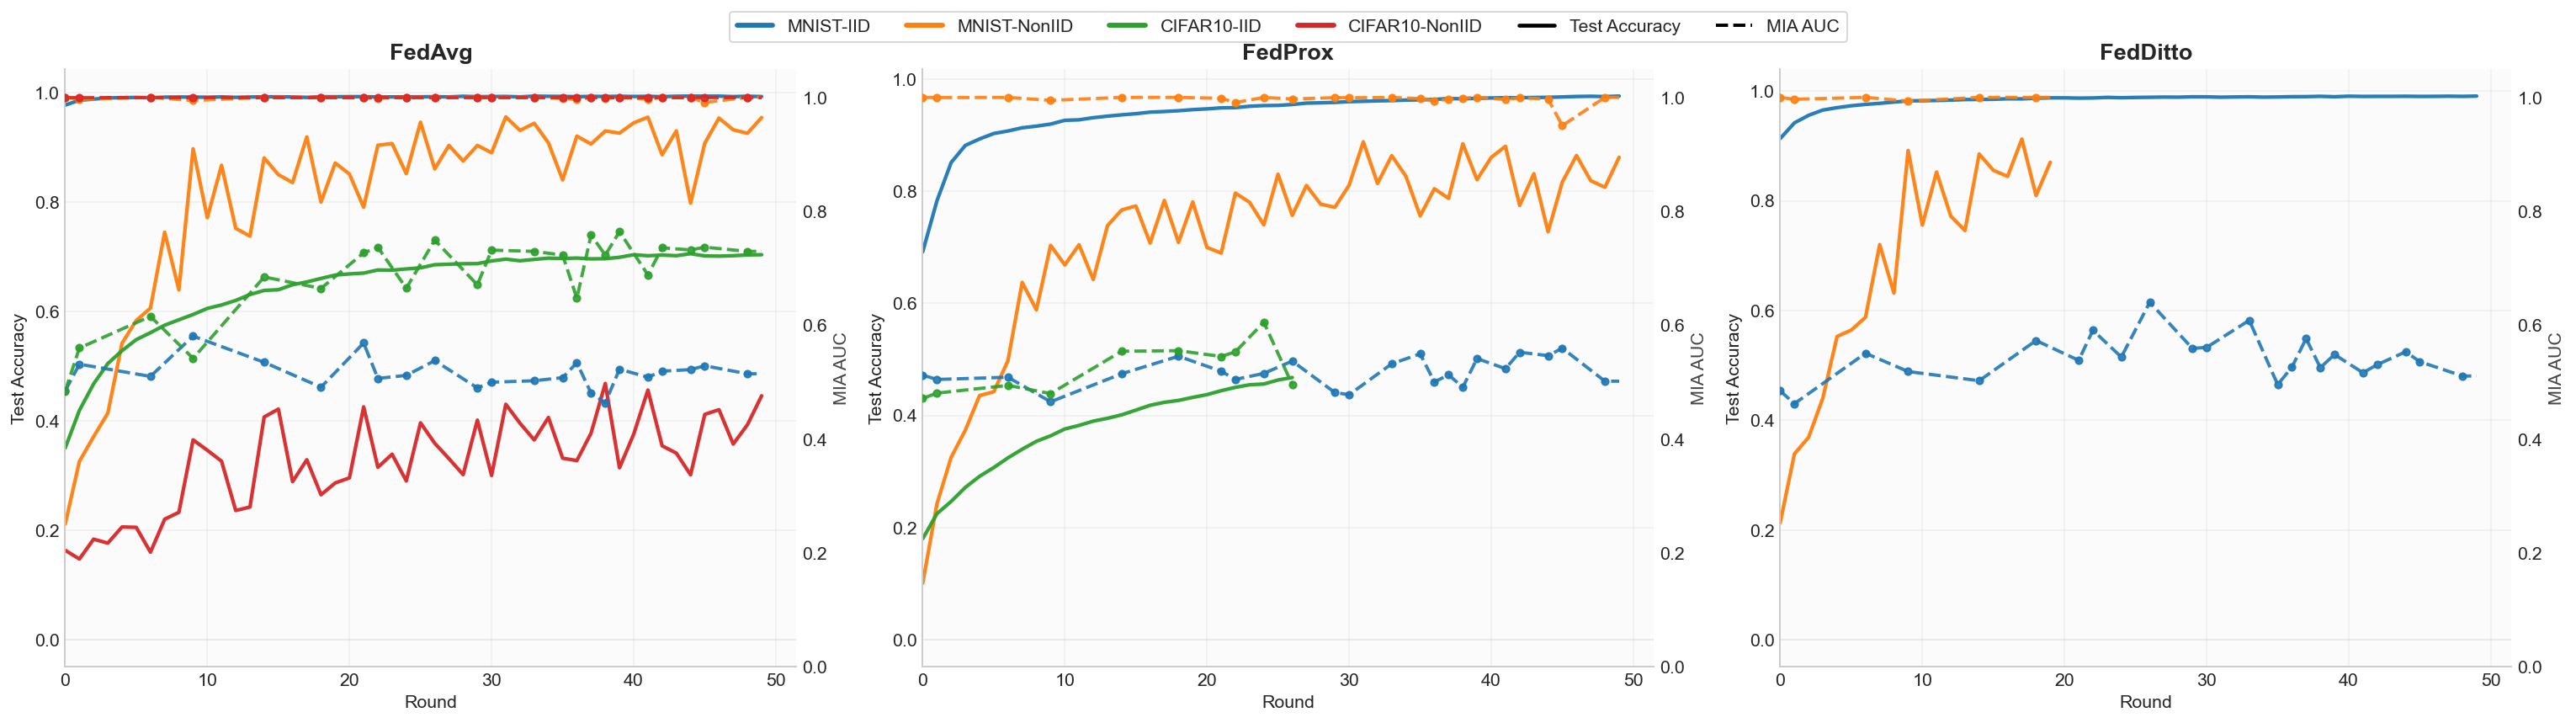

In [11]:
plot_metric_vs_auc(
    df=df,
    primary_metric='test_accuracy',
    primary_label='Test Accuracy',
    title='FL Performance vs Membership Inference Risk: Accuracy and MIA AUC',
)
plt.show()

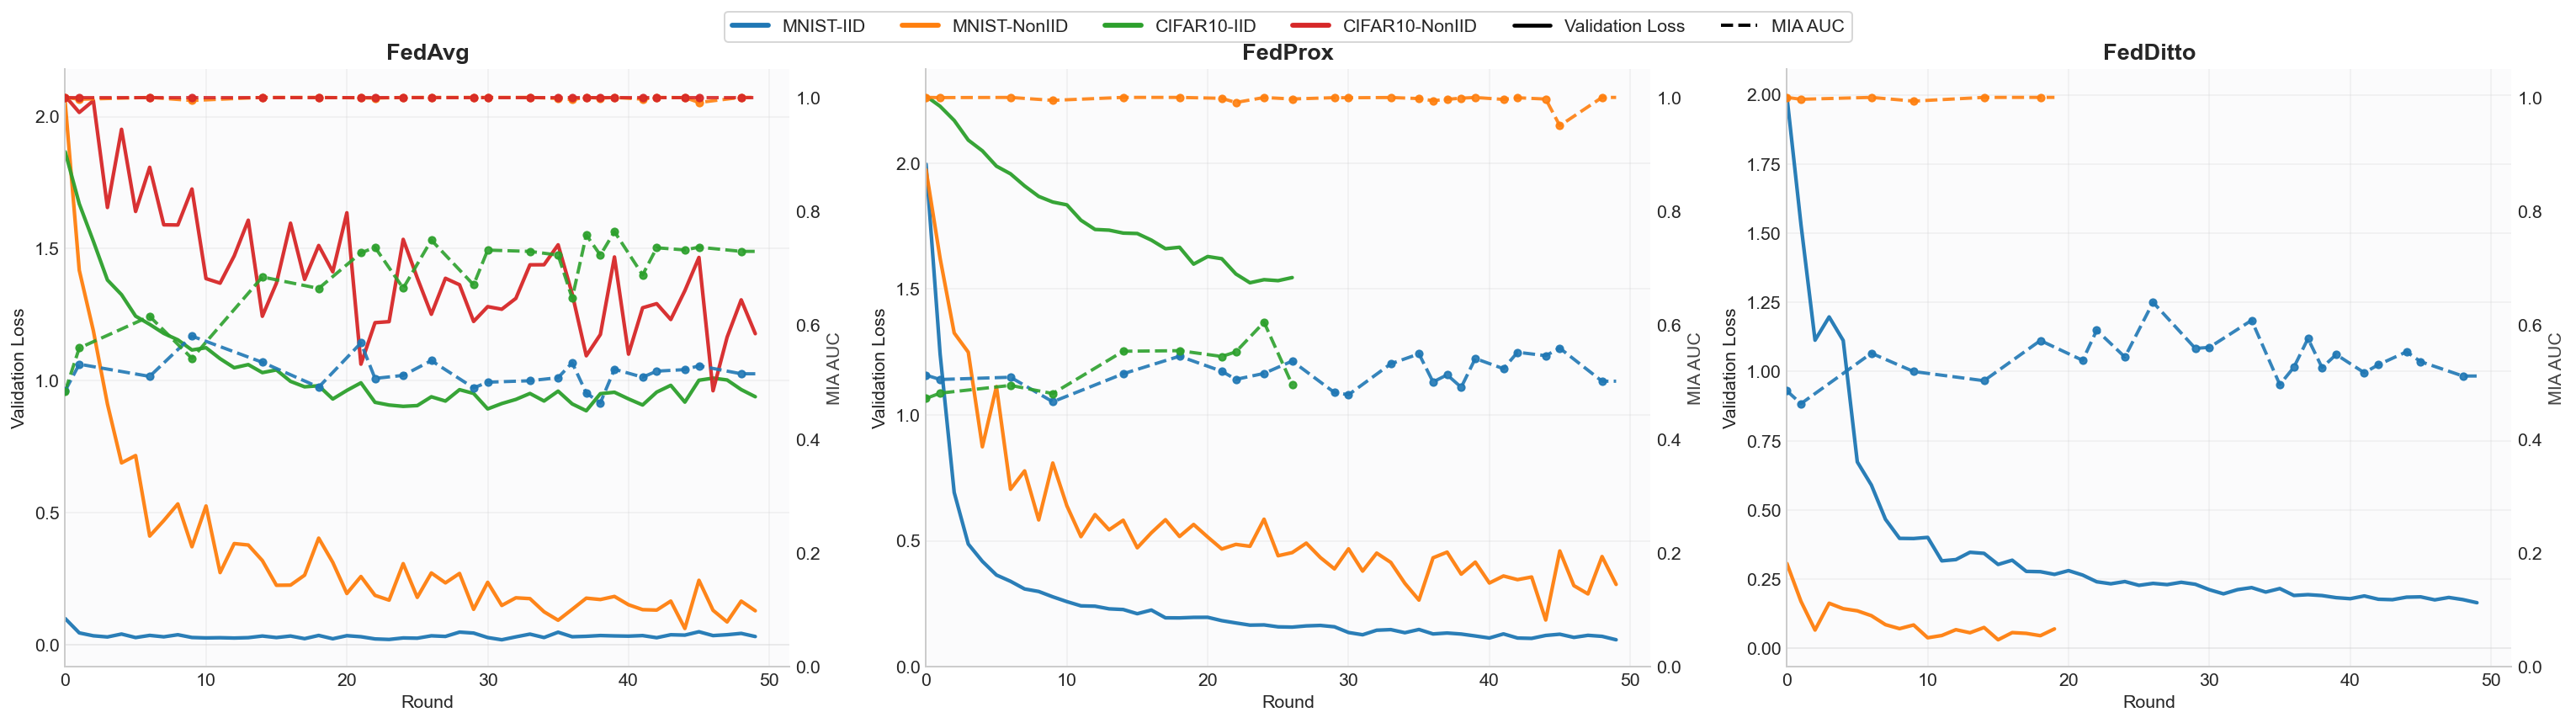

In [12]:
plot_metric_vs_auc(
    df=df,
    primary_metric='val_loss',
    primary_label='Validation Loss',
    title='FL Generalization vs Membership Inference Risk: Val Loss and MIA AUC',
)
plt.show()

## Notes

- 颜色编码数据集设定：同一种颜色对应同一个 `dataset-partition`
- 实线表示主指标（`Accuracy` 或 `Val Loss`）
- 虚线表示插值后的连续 `MIA AUC` 曲线，圆点表示实际有做 MIA 评估的轮次
- 左轴是主指标，右轴是 `MIA AUC`
- `shard` 在图中按 `NonIID` 标注

如果你后面补齐 `result/fedprox_MIA/*.jsonl` 和 `result/fedditto_MIA/*.jsonl`，这个 notebook 会自动把空子图补成完整的 8 条线。